MultiLinearRegression

In [105]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Exact filename from the dataset (case-sensitive!)
file_path = "multiple_linear_regression_dataset.csv"

# Preferred: newer function (if your version has it)
try:
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "hussainnasirkhan/multiple-linear-regression-dataset",
        file_path
    )
except AttributeError:
    # Fallback to older name if needed
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "hussainnasirkhan/multiple-linear-regression-dataset",
        file_path
    )

print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)          # Should be (20, 3)
print("Columns:", df.columns.tolist())  # ['age', 'experience', 'income']

Using Colab cache for faster access to the 'multiple-linear-regression-dataset' dataset.
First 5 rows:
    age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830

Shape: (20, 3)
Columns: ['age', 'experience', 'income']


In [106]:
X = df.iloc[:, 0:2].values
X

array([[25,  1],
       [30,  3],
       [47,  2],
       [32,  5],
       [43, 10],
       [51,  7],
       [28,  5],
       [33,  4],
       [37,  5],
       [39,  8],
       [29,  1],
       [47,  9],
       [54,  5],
       [51,  4],
       [44, 12],
       [41,  6],
       [58, 17],
       [23,  1],
       [44,  9],
       [37, 10]])

In [107]:
y = df['income'].values
y

array([30450, 35670, 31580, 40130, 47830, 41630, 41340, 37650, 40250,
       45150, 27840, 46110, 36720, 34800, 51300, 38900, 63600, 30870,
       44190, 48700])

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)


In [109]:
X_train

array([[32,  5],
       [44,  9],
       [51,  4],
       [47,  2],
       [44, 12],
       [37,  5],
       [23,  1],
       [58, 17],
       [37, 10],
       [54,  5],
       [47,  9],
       [30,  3],
       [25,  1],
       [41,  6],
       [43, 10],
       [39,  8]])

In [110]:
y_train

array([40130, 44190, 34800, 31580, 51300, 40250, 30870, 63600, 48700,
       36720, 46110, 35670, 30450, 38900, 47830, 45150])

In [111]:
import numpy as np

def fit():
  # Here we are adding bias to X_train 2d dataset so that it will be 3d with 1's
  X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
  Beta = np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train)

  print("--------For fit()  :-------")
  print("Intercept (β₀)  :", Beta[0])
  print("β_age           :", Beta[1])
  print("β_experience    :", Beta[2])
  return Beta

#fit()

In [112]:
p=np.insert(X_train,0,1,axis=1)
p

array([[ 1, 32,  5],
       [ 1, 44,  9],
       [ 1, 51,  4],
       [ 1, 47,  2],
       [ 1, 44, 12],
       [ 1, 37,  5],
       [ 1, 23,  1],
       [ 1, 58, 17],
       [ 1, 37, 10],
       [ 1, 54,  5],
       [ 1, 47,  9],
       [ 1, 30,  3],
       [ 1, 25,  1],
       [ 1, 41,  6],
       [ 1, 43, 10],
       [ 1, 39,  8]])

In [113]:
def predict(X_test):
   # Here also we are adding bias to X_test 2d dataset so that it will be 3d with 1's
  X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]
  y_pred = X_test_bias @ fit()  #it is also dot product
  print("\n--------For predict()  :-------")
  print(y_pred)
  return y_pred

#predict(X_test)

In [114]:
np.c_[np.ones((X_test.shape[0], 1)), X_test]

array([[ 1., 33.,  4.],
       [ 1., 29.,  1.],
       [ 1., 51.,  7.],
       [ 1., 28.,  5.]])

In [115]:
fit()
predict(X_test)

print("\nPredictions vs Actual:")
results = pd.DataFrame({
    'Age': X_test[:,0],
    'Experience': X_test[:,1],
    'Predicted Income': np.round(predict(X_test)).astype(int),
    'Actual Income': y_test
})
print(results)

--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043
--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043

--------For predict()  :-------
[36635.48165331 30643.15661129 41408.18996371 39184.65471259]

Predictions vs Actual:
--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043

--------For predict()  :-------
[36635.48165331 30643.15661129 41408.18996371 39184.65471259]
   Age  Experience  Predicted Income  Actual Income
0   33           4             36635          37650
1   29           1             30643          27840
2   51           7             41408          41630
3   28           5             39185          41340


--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043
--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043
--------For fit()  :-------
Intercept (β₀)  : 31055.90990026964
β_age           : -87.11548083087416
β_experience    : 2113.595655116043


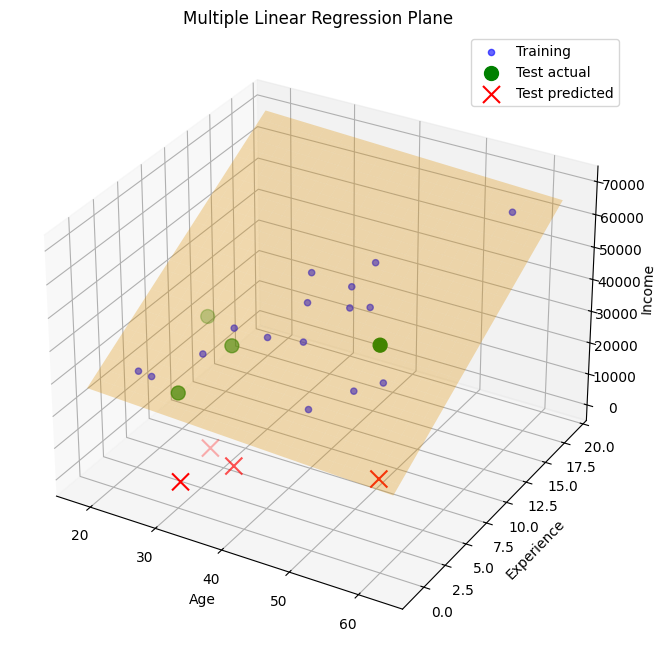

In [116]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Training points
ax.scatter(X_train[:,0], X_train[:,1], y_train, color='blue', alpha=0.6, label='Training')

# Test actual & predicted
ax.scatter(X_test[:,0], X_test[:,1], y_test, color='green', s=100, label='Test actual')
ax.scatter(X_test[:,0], X_test[:,1], y_pred, color='red', marker='x', s=150, label='Test predicted')

# Create mesh for the regression plane
x_surf = np.linspace(X[:,0].min()-5, X[:,0].max()+5, 30)
y_surf = np.linspace(X[:,1].min()-2, X[:,1].max()+2, 30)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Predict on grid using the fitted model coefficients
# (using sklearn model.coef_ and intercept_)
z_surf = fit()[0] + fit()[1]*x_surf + fit()[2]*y_surf

ax.plot_surface(x_surf, y_surf, z_surf, color='orange', alpha=0.3)

ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
ax.set_title('Multiple Linear Regression Plane')
ax.legend()
plt.show()